
# Dataset Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yfinance as yf

sns.set_theme(style='whitegrid', font_scale=1.1)

BASE = Path('..').resolve()
NEWS_DIR = BASE / 'Processed_Data' / 'news_sentiment_daily'
TWEETS_DIR = BASE / 'Processed_Data' / 'tweets_sentiment_daily'
RAW_NEWS_DIR = BASE / 'Raw_Data' / 'gdelt_news_data'
RAW_TWEETS_DIR = BASE / 'Raw_Data' / 'Tweets'
REPORT_DIR = BASE / 'Report'
DIAGRAMS_DIR = BASE / 'Diagrams'

TICKERS = [
    'AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL',
    'HD',   'JNJ',  'JPM',  'LLY',   'MA',
    'META', 'MSFT', 'NVDA', 'ORCL',  'PG',
    'TSLA', 'UNH',  'V',    'WMT',   'XOM',
]

SECTORS = {
    'AAPL': 'Technology', 'AVGO': 'Technology', 'MSFT': 'Technology',
    'NVDA': 'Technology', 'ORCL': 'Technology',
    'AMZN': 'Consumer Disc.', 'HD': 'Consumer Disc.', 'TSLA': 'Consumer Disc.',
    'GOOGL': 'Communication', 'META': 'Communication',
    'BRK-B': 'Financials', 'JPM': 'Financials', 'MA': 'Financials', 'V': 'Financials',
    'JNJ': 'Healthcare', 'LLY': 'Healthcare', 'UNH': 'Healthcare',
    'PG': 'Consumer Staples', 'WMT': 'Consumer Staples',
    'XOM': 'Energy',
}

print(f'Tickers: {len(TICKERS)}')
print(f'Sectors: {len(set(SECTORS.values()))}')

# Consistent sector colour palette
SECTOR_COLOURS = {
    "Communication": "#1b7837",
    "Consumer Disc.": "#c51b7d",
    "Consumer Staples": "#cc0000",
    "Energy": "#d95f02",
    "Financials": "#7570b3",
    "Healthcare": "#e7298a",
    "Technology": "#1f78b4",
}

def ticker_colour(t):
    return SECTOR_COLOURS[SECTORS[t]]

Tickers: 20
Sectors: 7


## 1. Load Processed Sentiment Data

In [2]:
news_frames = {}
tweet_frames = {}

for t in TICKERS:
    # News
    nf = NEWS_DIR / f'{t}_news_sentiment_daily.csv'
    if nf.exists():
        news_frames[t] = pd.read_csv(nf, parse_dates=['date'])

    # Tweets (BRK-B in news vs BRK.B in tweets)
    tweet_ticker = t.replace('-', '.') if t == 'BRK-B' else t
    tf = TWEETS_DIR / f'{tweet_ticker}_tweets_sentiment_daily.csv'
    if tf.exists():
        tweet_frames[t] = pd.read_csv(tf, parse_dates=['date'])

print(f'News tickers loaded:  {len(news_frames)}')
print(f'Tweet tickers loaded: {len(tweet_frames)}')

total_news = sum(len(df) for df in news_frames.values())
total_tweets = sum(len(df) for df in tweet_frames.values())
print(f'Total news records:   {total_news:,}')
print(f'Total tweet records:  {total_tweets:,}')

all_news_dates = pd.concat([df['date'] for df in news_frames.values()])
all_tweet_dates = pd.concat([df['date'] for df in tweet_frames.values()])
print(f'News date range:  {all_news_dates.min().date()} to {all_news_dates.max().date()}')
print(f'Tweet date range: {all_tweet_dates.min().date()} to {all_tweet_dates.max().date()}')

News tickers loaded:  20
Tweet tickers loaded: 20
Total news records:   11,557
Total tweet records:  13,278
News date range:  2023-08-01 to 2026-04-06
Tweet date range: 2023-08-01 to 2026-04-06


## 2. Language Detection on Raw Tweets (Lingua)

Use the Lingua library to detect the language distribution across all raw tweets, demonstrating why non-English filtering was necessary in the preprocessing pipeline.

Total tweets processed: 874,463
Skipped (< 20 chars):   44,752

All detected languages (67):
  ENGLISH          608,511  (69.59%)
  UNKNOWN          155,504  (17.78%)
  JAPANESE          23,159  (2.65%)
  KOREAN            20,514  (2.35%)
  SPANISH           14,545  (1.66%)
  ARABIC             6,171  (0.71%)
  FRENCH             5,096  (0.58%)
  WELSH              4,812  (0.55%)
  GERMAN             4,492  (0.51%)
  TURKISH            3,039  (0.35%)
  CHINESE            2,952  (0.34%)
  YORUBA             2,807  (0.32%)
  DUTCH              2,717  (0.31%)
  ESPERANTO          2,307  (0.26%)
  SOTHO              1,987  (0.23%)
  POLISH             1,789  (0.20%)
  ITALIAN            1,773  (0.20%)
  AFRIKAANS          1,596  (0.18%)
  SWEDISH            1,567  (0.18%)
  PORTUGUESE         1,266  (0.14%)
  NYNORSK              768  (0.09%)
  HEBREW               725  (0.08%)
  TAGALOG              684  (0.08%)
  CZECH                655  (0.07%)
  DANISH               603  (0.07%)
  THA

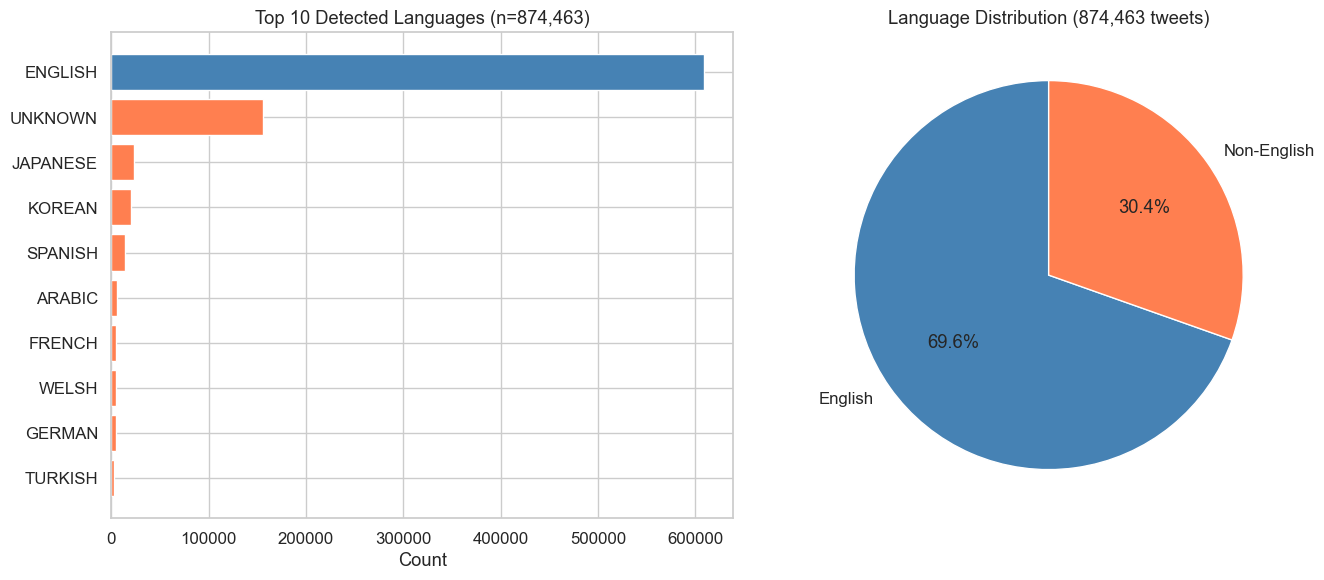

In [3]:
from lingua import LanguageDetectorBuilder

# Use all spoken languages with a minimum distance to reduce false positives
detector = LanguageDetectorBuilder.from_all_spoken_languages().with_minimum_relative_distance(0.25).with_preloaded_language_models().build()

# Run through ALL raw tweets
lang_counts = {}
total = 0
skipped = 0

for t in TICKERS:
    tweet_ticker = t.replace('-', '.') if t == 'BRK-B' else t
    rtf = RAW_TWEETS_DIR / f'tweets_{tweet_ticker}.csv'
    if rtf.exists():
        df = pd.read_csv(rtf, usecols=['body'])
        for text in df['body'].dropna():
            text = str(text).strip()
            if len(text) < 20:
                skipped += 1
                continue
            detected = detector.detect_language_of(text)
            lang_name = detected.name if detected else 'UNKNOWN'
            lang_counts[lang_name] = lang_counts.get(lang_name, 0) + 1
            total += 1

lang_df = pd.Series(lang_counts).sort_values(ascending=False)
lang_df_pct = (lang_df / lang_df.sum() * 100).round(2)

print(f'Total tweets processed: {total:,}')
print(f'Skipped (< 20 chars):   {skipped:,}')
print(f'\nAll detected languages ({len(lang_df)}):')
for lang, count in lang_df.items():
    print(f'  {lang:<15} {count:>8,}  ({lang_df_pct[lang]:.2f}%)')

non_english = total - lang_counts.get('ENGLISH', 0)
non_english_pct = non_english / total * 100
print(f'\nNon-English tweets: {non_english:,} ({non_english_pct:.1f}%)')

# Plot top 10 languages
top10 = lang_df.head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colours = ['steelblue' if l == 'ENGLISH' else 'coral' for l in top10.index]
axes[0].barh(top10.index[::-1], top10.values[::-1], color=colours[::-1])
axes[0].set_title(f'Top 10 Detected Languages (n={total:,})')
axes[0].set_xlabel('Count')

eng = lang_counts.get('ENGLISH', 0)
axes[1].pie([eng, non_english], labels=['English', 'Non-English'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'],
            startangle=90)
axes[1].set_title(f'Language Distribution ({total:,} tweets)')

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_tweets_language.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Tweet Content Breakdown

Analyse the prevalence of links, messaging platform spam, hashtags, and other non-text content in the raw tweets to justify the multi-stage filtering pipeline.


Total raw tweets analysed: 919,215

Content breakdown:
  Plain text only                                     541,262  (58.9%)
  Contains 5+ cashtags                                210,158  (22.9%)
  Contains domain link (.com/.io/.me/.org/.net)       117,743  (12.8%)
  Contains hashtag (#)                                117,489  (12.8%)
  Contains Discord                                     90,418  (9.8%)
  Contains WhatsApp (wa.me)                            44,622  (4.9%)
  Contains Telegram (t.me)                              5,978  (0.7%)
  Contains 8+ hashtags                                  3,826  (0.4%)
  Contains URL (http)                                     355  (0.0%)
  Contains media reference                                  2  (0.0%)


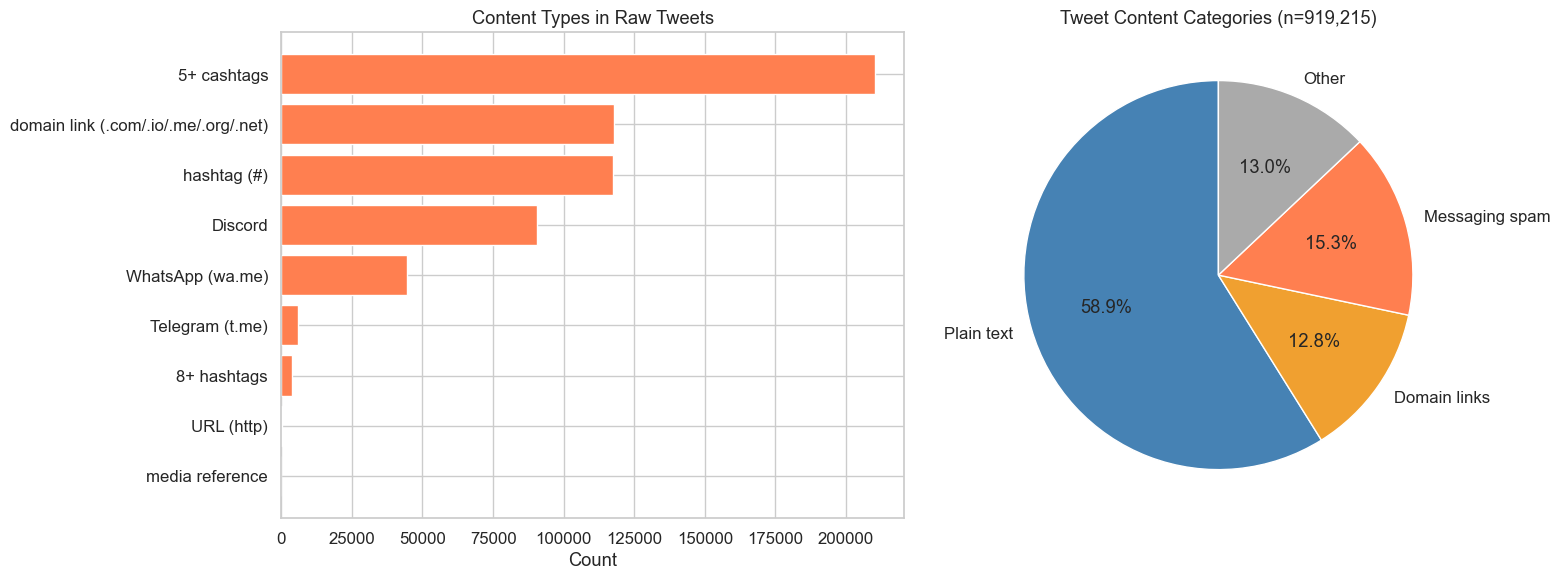

In [4]:
import re

# Analyse ALL raw tweets for content types
content_counts = {
    'Contains URL (http)': 0,
    'Contains domain link (.com/.io/.me/.org/.net)': 0,
    'Contains WhatsApp (wa.me)': 0,
    'Contains Discord': 0,
    'Contains Telegram (t.me)': 0,
    'Contains hashtag (#)': 0,
    'Contains 5+ cashtags': 0,
    'Contains 8+ hashtags': 0,
    'Contains media reference': 0,
    'Plain text only': 0,
}
total_tweets = 0

for t in TICKERS:
    tweet_ticker = t.replace('-', '.') if t == 'BRK-B' else t
    rtf = RAW_TWEETS_DIR / f'tweets_{tweet_ticker}.csv'
    if rtf.exists():
        df = pd.read_csv(rtf, usecols=['body'])
        for text in df['body'].dropna():
            text = str(text)
            total_tweets += 1
            has_any = False
            # Regex Definitions:
            if 'http' in text.lower():
                content_counts['Contains URL (http)'] += 1
                has_any = True
            if re.search(r'\.com|\.io|\.me|\.org|\.net', text, re.IGNORECASE):
                content_counts['Contains domain link (.com/.io/.me/.org/.net)'] += 1
                has_any = True
            if 'wa.me' in text.lower() or 'whatsapp' in text.lower():
                content_counts['Contains WhatsApp (wa.me)'] += 1
                has_any = True
            if 'discord' in text.lower():
                content_counts['Contains Discord'] += 1
                has_any = True
            if 't.me/' in text.lower() or 'telegram' in text.lower():
                content_counts['Contains Telegram (t.me)'] += 1
                has_any = True
            if '#' in text:
                content_counts['Contains hashtag (#)'] += 1
                has_any = True
            cashtag_count = len(re.findall(r'\$[A-Z]{1,5}', text))
            if cashtag_count >= 5:
                content_counts['Contains 5+ cashtags'] += 1
                has_any = True
            hashtag_count = text.count('#')
            if hashtag_count >= 8:
                content_counts['Contains 8+ hashtags'] += 1
                has_any = True
            if any(x in text.lower() for x in ['pic.twitter', 'pbs.twimg', 'video.twimg']):
                content_counts['Contains media reference'] += 1
                has_any = True
            if not has_any:
                content_counts['Plain text only'] += 1


print(f'\nTotal raw tweets analysed: {total_tweets:,}')
print(f'\nContent breakdown:')
for label, count in sorted(content_counts.items(), key=lambda x: -x[1]):
    pct = count / total_tweets * 100
    print(f'  {label:<50} {count:>8,}  ({pct:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of content types (exclude plain text for clarity)
labels = []
values = []
for label, count in sorted(content_counts.items(), key=lambda x: -x[1]):
    if label != 'Plain text only' and count > 0:
        labels.append(label.replace('Contains ', ''))
        values.append(count)

axes[0].barh(labels[::-1], values[::-1], color='coral')
axes[0].set_title('Content Types in Raw Tweets')
axes[0].set_xlabel('Count')

# Pie chart: messaging spam vs other
messaging_spam = (content_counts['Contains WhatsApp (wa.me)'] +
                  content_counts['Contains Discord'] +
                  content_counts['Contains Telegram (t.me)'])
links = content_counts['Contains domain link (.com/.io/.me/.org/.net)']
clean = content_counts['Plain text only']
other = total_tweets - messaging_spam - links - clean

axes[1].pie([clean, links, messaging_spam, other],
            labels=['Plain text', 'Domain links', 'Messaging spam', 'Other'],
            autopct='%1.1f%%',
            colors=['steelblue', '#f0a030', 'coral', '#aaaaaa'],
            startangle=90)
axes[1].set_title(f'Tweet Content Categories (n={total_tweets:,})')

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_tweets_content_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Word Count Distribution

Compare the word count distributions of raw news headlines and raw tweets to understand text length characteristics of each source.

News headlines: 90,413 texts
  Mean word count:   14.8
  Median word count: 13
  Min: 1, Max: 59

Tweets: 919,215 texts
  Mean word count:   23.1
  Median word count: 21
  Min: 1, Max: 89


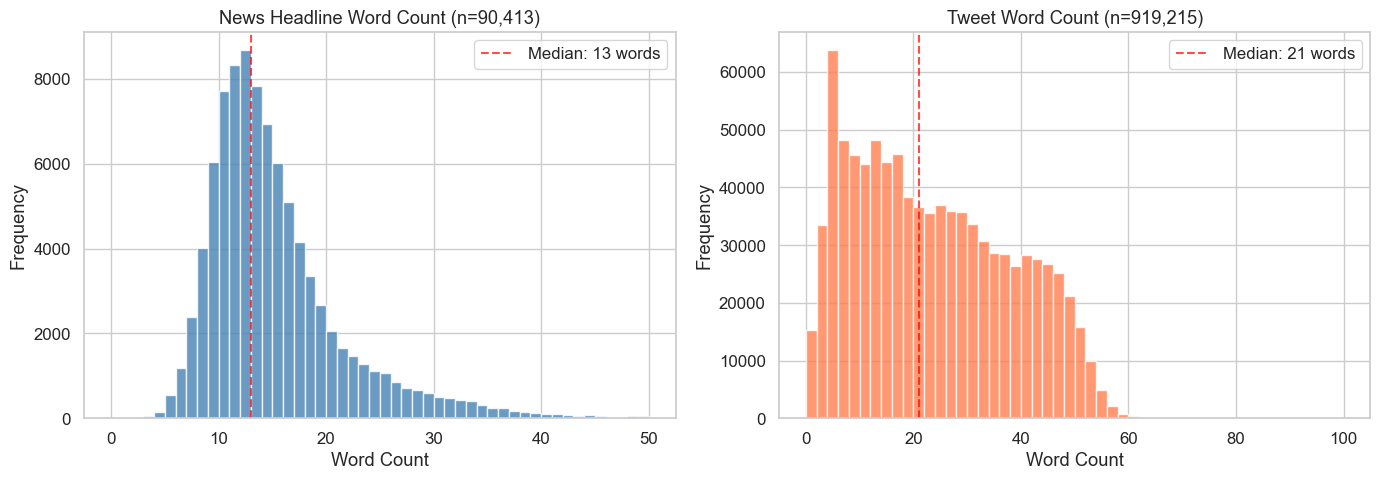

In [5]:
# Collect word counts from all raw data
news_word_counts = []
tweet_word_counts = []

for t in TICKERS:
    # News headlines
    rnf = RAW_NEWS_DIR / f'{t}_news.csv'
    if rnf.exists():
        df = pd.read_csv(rnf, usecols=['headline'])
        for text in df['headline'].dropna():
            news_word_counts.append(len(str(text).split()))

    # Tweets
    tweet_ticker = t.replace('-', '.') if t == 'BRK-B' else t
    rtf = RAW_TWEETS_DIR / f'tweets_{tweet_ticker}.csv'
    if rtf.exists():
        df = pd.read_csv(rtf, usecols=['body'])
        for text in df['body'].dropna():
            tweet_word_counts.append(len(str(text).split()))

news_wc = pd.Series(news_word_counts)
tweet_wc = pd.Series(tweet_word_counts)

print(f'News headlines: {len(news_wc):,} texts')
print(f'  Mean word count:   {news_wc.mean():.1f}')
print(f'  Median word count: {news_wc.median():.0f}')
print(f'  Min: {news_wc.min()}, Max: {news_wc.max()}')

print(f'\nTweets: {len(tweet_wc):,} texts')
print(f'  Mean word count:   {tweet_wc.mean():.1f}')
print(f'  Median word count: {tweet_wc.median():.0f}')
print(f'  Min: {tweet_wc.min()}, Max: {tweet_wc.max()}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(news_wc, bins=50, color='steelblue', edgecolor='white', alpha=0.8, range=(0, 50))
axes[0].axvline(news_wc.median(), color='red', linestyle='--', alpha=0.7,
                label=f'Median: {news_wc.median():.0f} words')
axes[0].set_title(f'News Headline Word Count (n={len(news_wc):,})')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(tweet_wc, bins=50, color='coral', edgecolor='white', alpha=0.8, range=(0, 100))
axes[1].axvline(tweet_wc.median(), color='red', linestyle='--', alpha=0.7,
                label=f'Median: {tweet_wc.median():.0f} words')
axes[1].set_title(f'Tweet Word Count (n={len(tweet_wc):,})')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Raw Data Counts

In [6]:
raw_news_counts = {}
raw_tweet_counts = {}

for t in TICKERS:
    rnf = RAW_NEWS_DIR / f'{t}_news.csv'
    if rnf.exists():
        raw_news_counts[t] = len(pd.read_csv(rnf).dropna(subset=['headline']))
    tweet_ticker = t.replace('-', '.') if t == 'BRK-B' else t
    rtf = RAW_TWEETS_DIR / f'tweets_{tweet_ticker}.csv'
    if rtf.exists():
        raw_tweet_counts[t] = len(pd.read_csv(rtf).dropna(subset=['body']))

counts_df = pd.DataFrame({
    'Ticker': TICKERS,
    'Sector': [SECTORS[t] for t in TICKERS],
    'Raw News': [raw_news_counts.get(t, 0) for t in TICKERS],
    'Raw Tweets': [raw_tweet_counts.get(t, 0) for t in TICKERS],
    'News Days': [len(news_frames[t]) if t in news_frames else 0 for t in TICKERS],
    'Tweet Days': [len(tweet_frames[t]) if t in tweet_frames else 0 for t in TICKERS],
}).set_index('Ticker').sort_values('Raw News', ascending=False)

print('=' * 70)
print('NEWS DATA SUMMARY')
print(f'  Files:          {len(raw_news_counts)} tickers')
print(f'  Total articles: {sum(raw_news_counts.values()):,}')
print(f'  Max:            {max(raw_news_counts, key=raw_news_counts.get)} ({max(raw_news_counts.values()):,})')
print(f'  Min:            {min(raw_news_counts, key=raw_news_counts.get)} ({min(raw_news_counts.values()):,})')
print(f'  Ratio max/min:  {max(raw_news_counts.values())/min(raw_news_counts.values()):.1f}x')
print()
print('=' * 70)
print('TWEET DATA SUMMARY')
print(f'  Files:          {len(raw_tweet_counts)} tickers')
print(f'  Total tweets:   {sum(raw_tweet_counts.values()):,}')
print(f'  Max:            {max(raw_tweet_counts, key=raw_tweet_counts.get)} ({max(raw_tweet_counts.values()):,})')
print(f'  Min:            {min(raw_tweet_counts, key=raw_tweet_counts.get)} ({min(raw_tweet_counts.values()):,})')
print(f'  Ratio max/min:  {max(raw_tweet_counts.values())/min(raw_tweet_counts.values()):.1f}x')
print()
print('=' * 70)
print('PER-SECTOR SUMMARY')
sector_summary = counts_df.groupby('Sector').agg(
    Tickers=('Raw News', 'count'),
    News=('Raw News', 'sum'),
    Tweets=('Raw Tweets', 'sum'),
).sort_values('News', ascending=False)
display(sector_summary)
print()
display(counts_df)

NEWS DATA SUMMARY
  Files:          20 tickers
  Total articles: 90,413
  Max:            NVDA (14,705)
  Min:            V (508)
  Ratio max/min:  28.9x

TWEET DATA SUMMARY
  Files:          20 tickers
  Total tweets:   919,215
  Max:            TSLA (103,942)
  Min:            PG (21,167)
  Ratio max/min:  4.9x

PER-SECTOR SUMMARY


,Tickers,News,Tweets
Sector,,,
Technology,5,34909,246830
Communication,2,16215,102063
Consumer Disc.,3,16081,207605
Financials,4,11186,132464
Healthcare,3,6440,125053
Consumer Staples,2,4082,61076
Energy,1,1500,44124


,Sector,Raw News,Raw Tweets,News Days,Tweet Days
Ticker,,,,,
NVDA,Technology,14705,64097,661,669
MSFT,Technology,9271,67990,656,672
GOOGL,Communication,8694,49000,660,666
TSLA,Consumer Disc.,8063,103942,652,663
META,Communication,7521,53063,660,669
AMZN,Consumer Disc.,6620,78563,644,669
AAPL,Technology,5466,57188,658,671
BRK-B,Financials,5118,25504,645,671
JPM,Financials,3948,46165,629,670


## 6. Coverage by Ticker

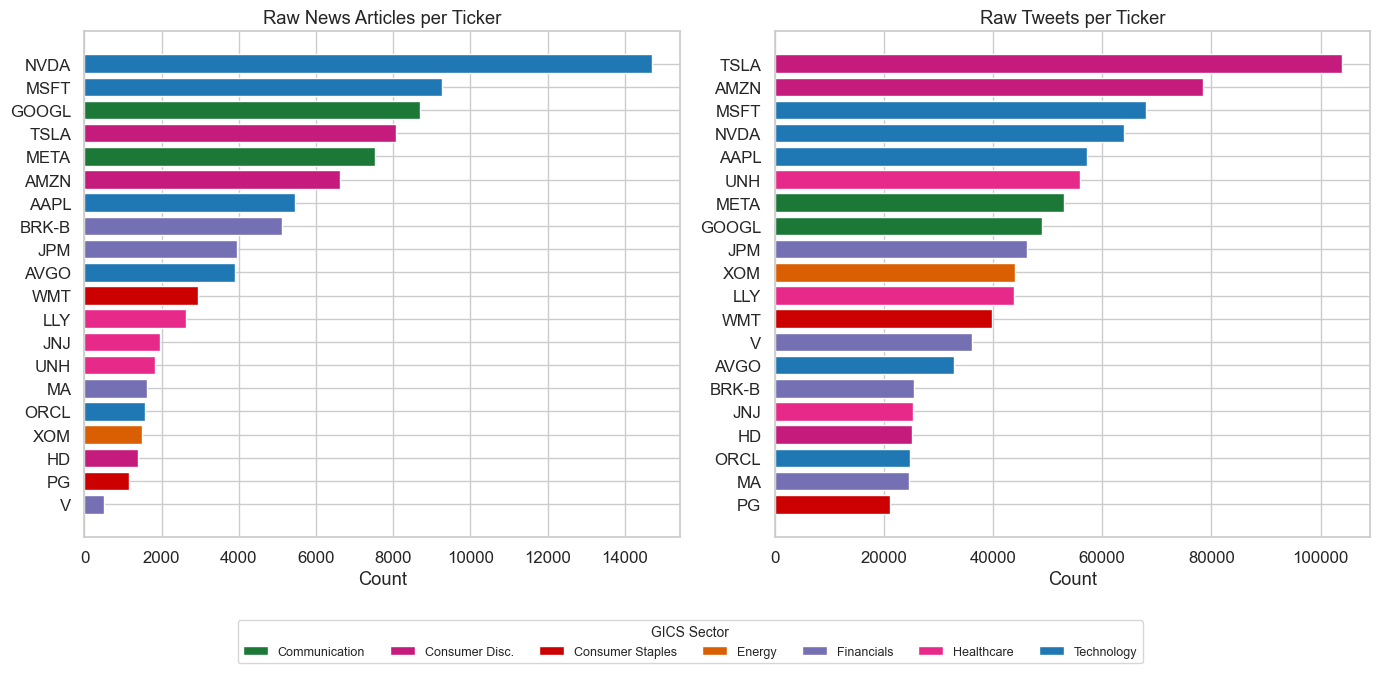

In [7]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 6.8))

sorted_news = counts_df.sort_values('Raw News', ascending=True).index
axes[0].barh(sorted_news, counts_df.loc[sorted_news, 'Raw News'],
             color=[ticker_colour(t) for t in sorted_news])
axes[0].set_title('Raw News Articles per Ticker')
axes[0].set_xlabel('Count')

sorted_tweets = counts_df.sort_values('Raw Tweets', ascending=True).index
axes[1].barh(sorted_tweets, counts_df.loc[sorted_tweets, 'Raw Tweets'],
             color=[ticker_colour(t) for t in sorted_tweets])
axes[1].set_title('Raw Tweets per Ticker')
axes[1].set_xlabel('Count')

legend_els = [Patch(facecolor=SECTOR_COLOURS[s], label=s) for s in sorted(SECTOR_COLOURS)]
fig.legend(handles=legend_els, loc='lower center', ncol=7, fontsize=9,
           title='GICS Sector', title_fontsize=10,
           bbox_to_anchor=(0.5, 0.0), frameon=True)

plt.tight_layout(rect=[0, 0.09, 1, 1])
fig.savefig(DIAGRAMS_DIR / 'EDA/data_coverage_by_ticker.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Sentiment Distribution

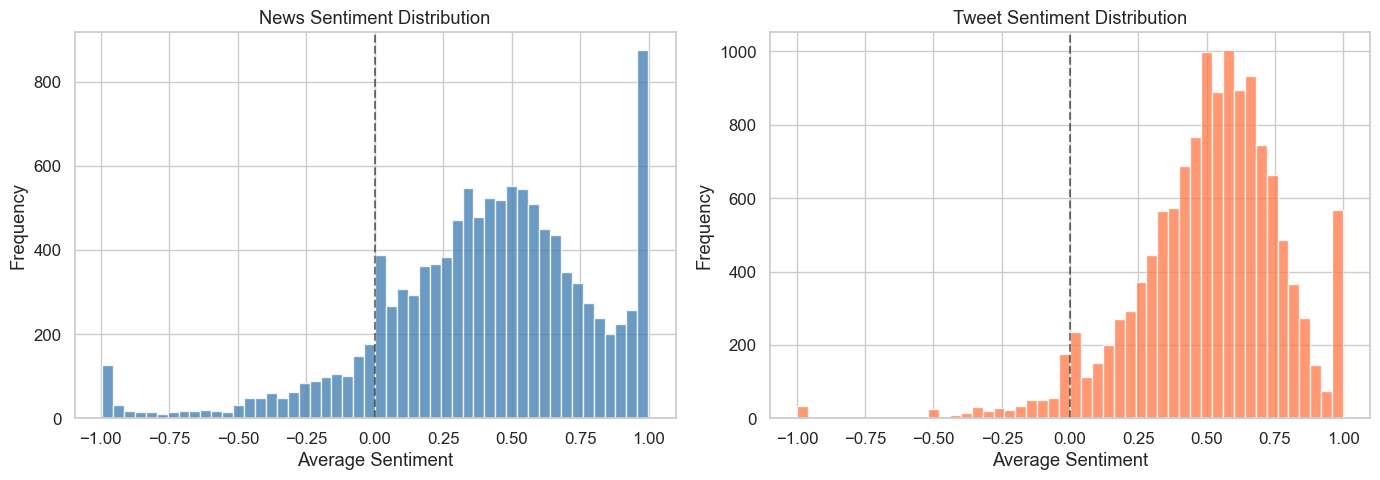

News sentiment  - mean: 0.4005, std: 0.3930
Tweet sentiment - mean: 0.5084, std: 0.2710


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_news_sent = pd.concat([df[['avg_sentiment']] for df in news_frames.values()])
all_tweet_sent = pd.concat([df[['avg_sentiment']] for df in tweet_frames.values()])

axes[0].hist(all_news_sent['avg_sentiment'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('News Sentiment Distribution')
axes[0].set_xlabel('Average Sentiment')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)

axes[1].hist(all_tweet_sent['avg_sentiment'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Tweet Sentiment Distribution')
axes[1].set_xlabel('Average Sentiment')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'News sentiment  - mean: {all_news_sent["avg_sentiment"].mean():.4f}, std: {all_news_sent["avg_sentiment"].std():.4f}')
print(f'Tweet sentiment - mean: {all_tweet_sent["avg_sentiment"].mean():.4f}, std: {all_tweet_sent["avg_sentiment"].std():.4f}')

## 7. Temporal Coverage

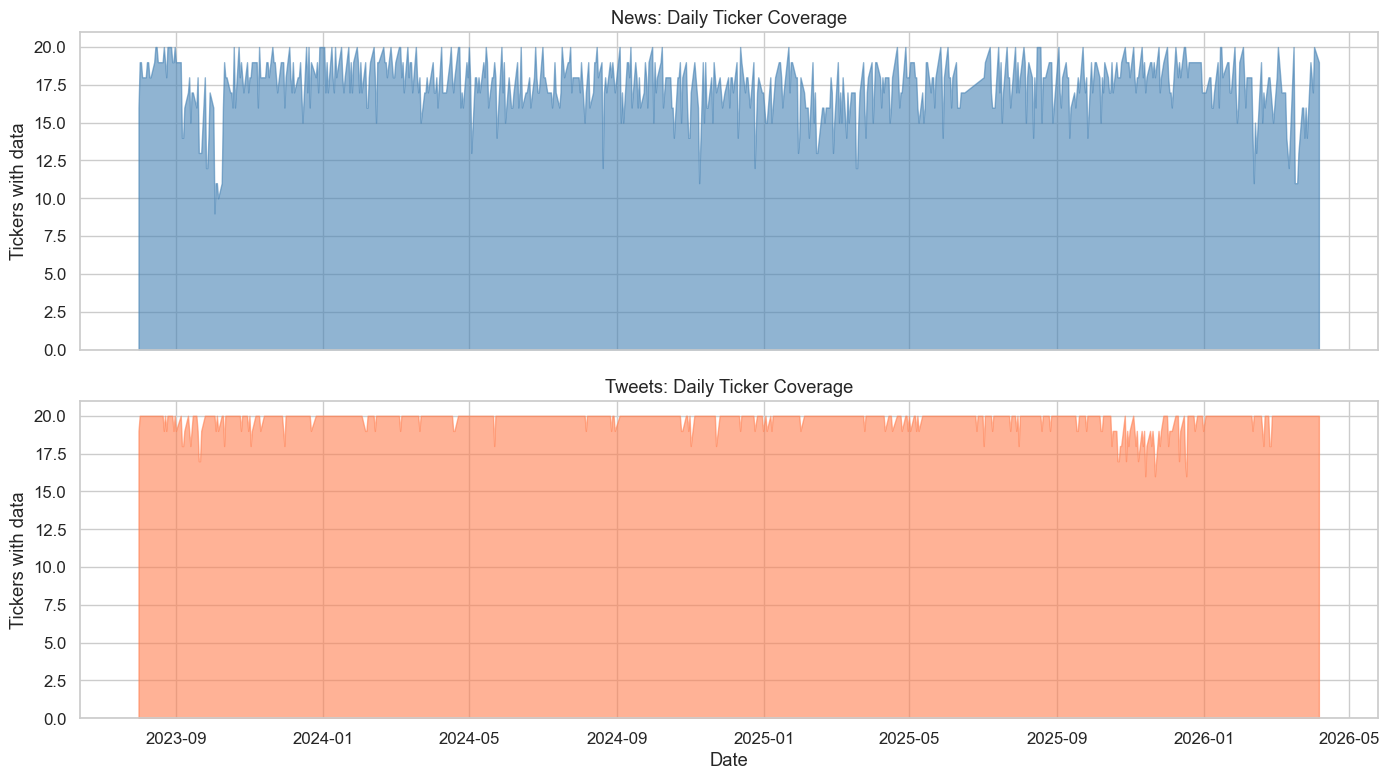

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, (frames, title, colour) in enumerate([
    (news_frames, 'News: Daily Ticker Coverage', 'steelblue'),
    (tweet_frames, 'Tweets: Daily Ticker Coverage', 'coral'),
]):
    all_dates = pd.concat([df[['date']] for df in frames.values()])
    daily_count = all_dates.groupby('date').size()
    daily_count = daily_count.sort_index()
    axes[i].fill_between(daily_count.index, daily_count.values, alpha=0.6, color=colour)
    axes[i].set_title(title)
    axes[i].set_ylabel('Tickers with data')
    axes[i].set_ylim(0, 21)

axes[1].set_xlabel('Date')
plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_temporal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sentiment by Sector

C:\Users\Alasteir\AppData\Local\Temp\ipykernel_17460\3689517692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Sector', y='avg_sentiment', order=sector_order,
C:\Users\Alasteir\AppData\Local\Temp\ipykernel_17460\3689517692.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Sector', y='avg_sentiment', order=sector_order,


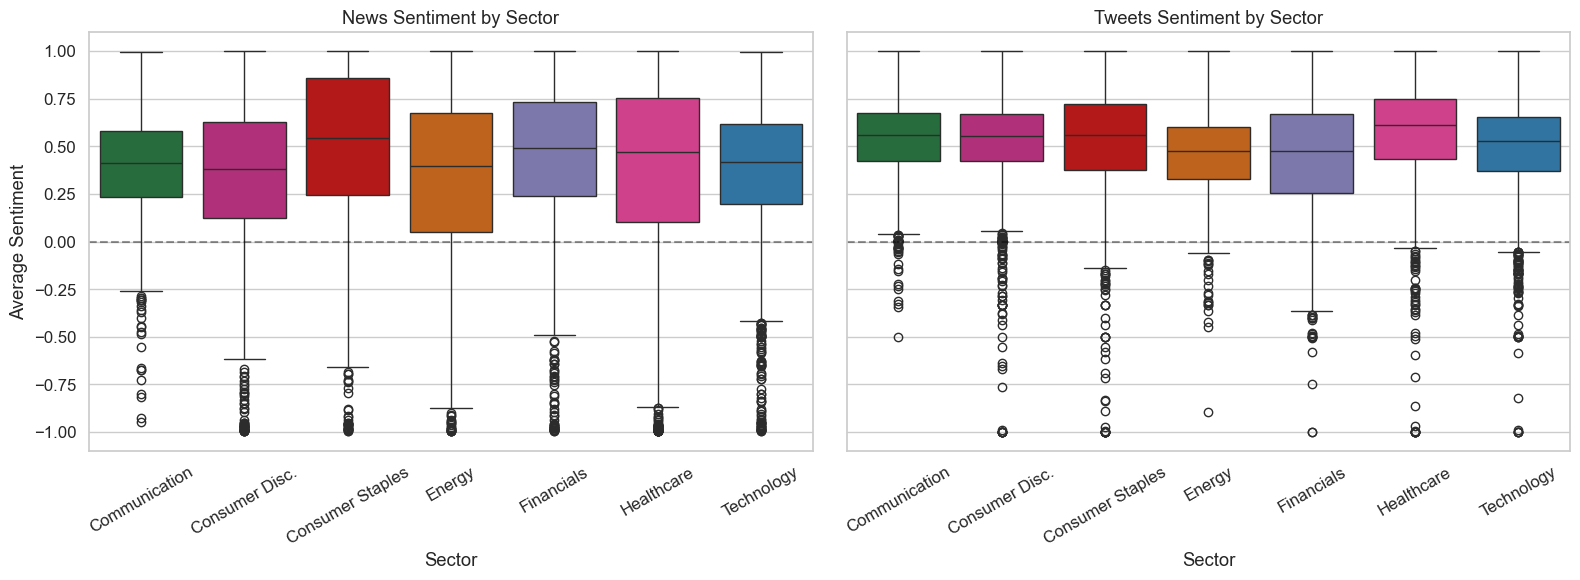

In [10]:
rows = []
for t, df in news_frames.items():
    for _, r in df.iterrows():
        rows.append({'Sector': SECTORS[t], 'Source': 'News', 'avg_sentiment': r['avg_sentiment']})
for t, df in tweet_frames.items():
    for _, r in df.iterrows():
        rows.append({'Sector': SECTORS[t], 'Source': 'Tweets', 'avg_sentiment': r['avg_sentiment']})

sector_df = pd.DataFrame(rows)
sector_order = sorted(SECTOR_COLOURS.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, src in enumerate(['News', 'Tweets']):
    subset = sector_df[sector_df['Source'] == src]
    sns.boxplot(data=subset, x='Sector', y='avg_sentiment', order=sector_order,
                ax=axes[i], palette=SECTOR_COLOURS)
    axes[i].set_title(f'{src} Sentiment by Sector')
    axes[i].set_xlabel('Sector')
    axes[i].set_ylabel('Average Sentiment')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(0, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_sentiment_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. News vs Tweet Sentiment Correlation

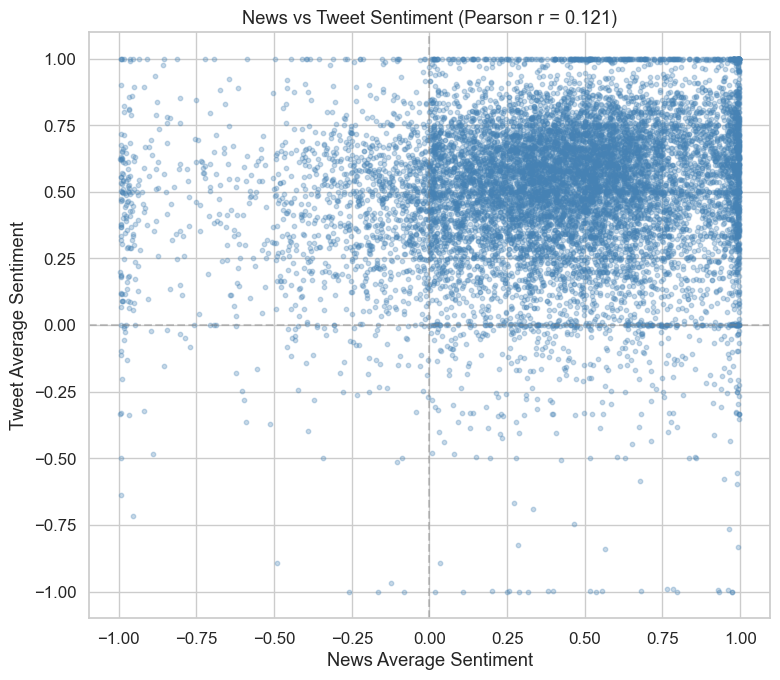

Pearson r = 0.1211  (n = 11,431 paired days)


In [11]:
merged_rows = []
for t in TICKERS:
    if t in news_frames and t in tweet_frames:
        m = pd.merge(news_frames[t][['date', 'avg_sentiment']],
                     tweet_frames[t][['date', 'avg_sentiment']],
                     on='date', suffixes=('_news', '_tweet'))
        merged_rows.append(m)

merged = pd.concat(merged_rows, ignore_index=True)

r = merged['avg_sentiment_news'].corr(merged['avg_sentiment_tweet'])

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(merged['avg_sentiment_news'], merged['avg_sentiment_tweet'],
           alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('News Average Sentiment')
ax.set_ylabel('Tweet Average Sentiment')
ax.set_title(f'News vs Tweet Sentiment (Pearson r = {r:.3f})')
ax.axhline(0, color='grey', linestyle='--', alpha=0.4)
ax.axvline(0, color='grey', linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_news_tweet_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r = {r:.4f}  (n = {len(merged):,} paired days)')

## 10. Session Assignment Analysis

Analyse how news articles and tweets are assigned to NYSE trading sessions using the 16:00 ET market-close cutoff.

TWEET SESSION ASSIGNMENT
  Total:                         919,215
  Before 16:00 ET (same day):    557,663 (60.7%)
  After 16:00 ET (next session): 361,552 (39.3%)



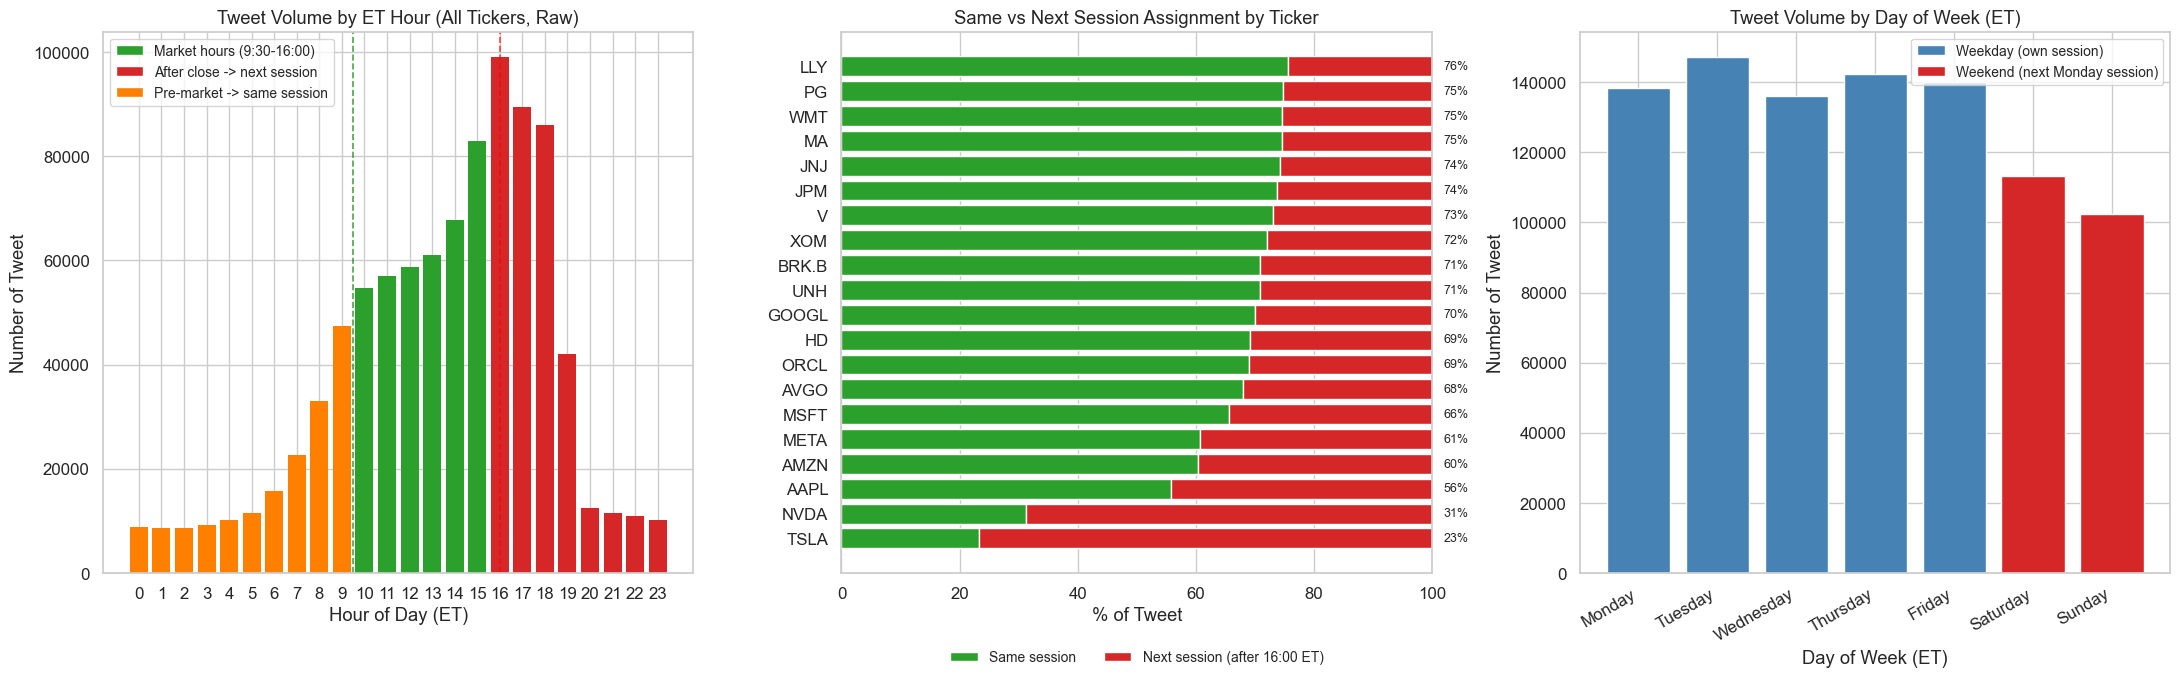

NEWS SESSION ASSIGNMENT
  Total:                         90,413
  Before 16:00 ET (same day):    61,032 (67.5%)
  After 16:00 ET (next session): 29,381 (32.5%)



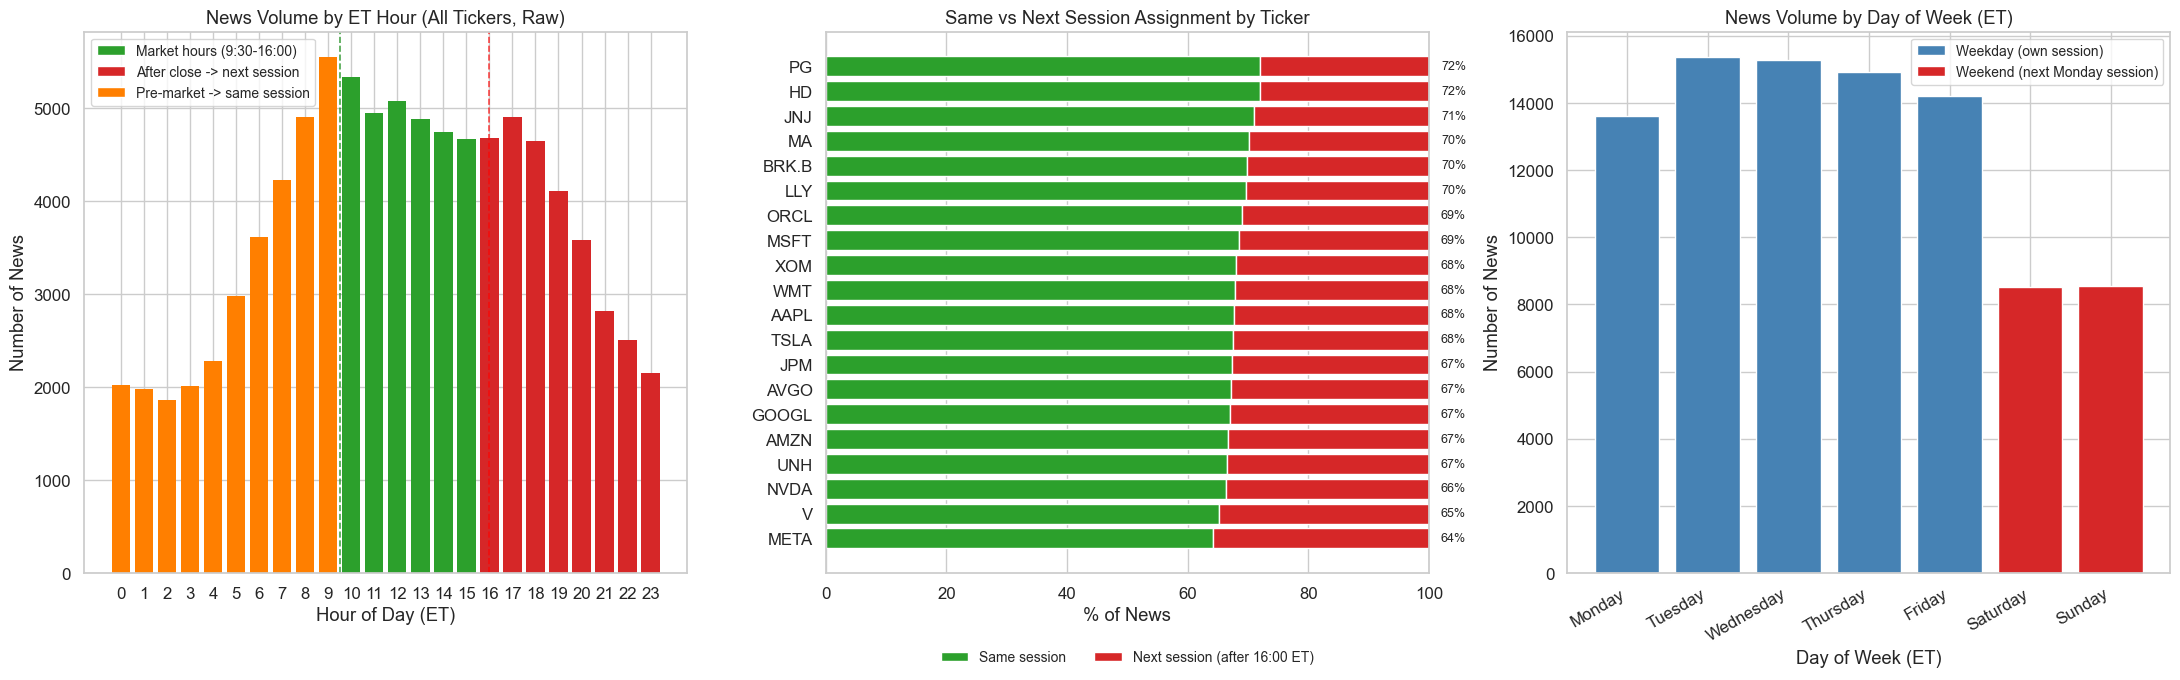

In [12]:
import exchange_calendars
from matplotlib.patches import Patch

nyse_cal = exchange_calendars.get_calendar('XNYS')

# ── Helper: collect timestamps, per-ticker session counts, hours, days ──
def collect_session_data(source='tweets'):
    """Return (hours_series, dows_series, ticker_same, ticker_total)."""
    all_hours, all_dows = [], []
    tk_same, tk_total = {}, {}

    for t in TICKERS:
        if source == 'tweets':
            tweet_ticker = t.replace('-', '.') if t == 'BRK-B' else t
            fpath = RAW_TWEETS_DIR / f'tweets_{tweet_ticker}.csv'
            date_col = 'post_date'
            text_col = 'body'
        else:
            fpath = RAW_NEWS_DIR / f'{t}_news.csv'
            date_col = 'date'
            text_col = 'headline'

        if not fpath.exists():
            continue
        df = pd.read_csv(fpath, usecols=[date_col, text_col])
        # Drop rows with missing text first, matching the post-NA counts
        # reported by the Raw Data Counts and content-breakdown cells.
        df = df.dropna(subset=[text_col])
        df['dt'] = pd.to_datetime(df[date_col], errors='coerce')
        df = df.dropna(subset=['dt'])
        if df['dt'].dt.tz is None:
            df['dt'] = df['dt'].dt.tz_localize('UTC')
        df['dt_et'] = df['dt'].dt.tz_convert('US/Eastern')
        df['hour'] = df['dt_et'].dt.hour
        df['dow'] = df['dt_et'].dt.dayofweek

        all_hours.extend(df['hour'].tolist())
        all_dows.extend(df['dow'].tolist())
        same = int((df['hour'] < 16).sum())
        tk_same[t] = same
        tk_total[t] = len(df)

    return pd.Series(all_hours), pd.Series(all_dows), tk_same, tk_total


def plot_session_panels(hours, dows, tk_same, tk_total, label, save_name):
    """Draw the 3-panel session-assignment figure."""
    total = sum(tk_total.values())
    total_same = sum(tk_same.values())
    total_next = total - total_same
    print(f'{label.upper()} SESSION ASSIGNMENT')
    print(f'  Total:                         {total:,}')
    print(f'  Before 16:00 ET (same day):    {total_same:,} ({total_same/total*100:.1f}%)')
    print(f'  After 16:00 ET (next session): {total_next:,} ({total_next/total*100:.1f}%)')
    print()

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # ── Panel 1: Volume by ET Hour ──
    ax = axes[0]
    hour_counts = hours.value_counts().sort_index().reindex(range(24), fill_value=0)

    colours_h = []
    for h in range(24):
        if h <= 9:
            colours_h.append('#ff7f00')   # orange: pre-market
        elif 10 <= h <= 15:
            colours_h.append('#2ca02c')   # green: market hours
        else:
            colours_h.append('#d62728')   # red: after close

    ax.bar(hour_counts.index, hour_counts.values, color=colours_h, edgecolor='none')
    ax.axvline(9.5, color='green', linestyle='--', alpha=0.7, linewidth=1.2)
    ax.axvline(16, color='red', linestyle='--', alpha=0.7, linewidth=1.2)
    ax.set_title(f'{label} Volume by ET Hour (All Tickers, Raw)')
    ax.set_xlabel('Hour of Day (ET)')
    ax.set_ylabel(f'Number of {label}')
    ax.set_xticks(range(24))
    ax.legend(handles=[
        Patch(facecolor='#2ca02c', label='Market hours (9:30-16:00)'),
        Patch(facecolor='#d62728', label='After close -> next session'),
        Patch(facecolor='#ff7f00', label='Pre-market -> same session'),
    ], loc='upper left', fontsize=10)

    # ── Panel 2: Same vs Next Session by Ticker (stacked %) ──
    ax = axes[1]
    same_pct = {t: tk_same[t] / tk_total[t] * 100 for t in TICKERS if t in tk_total}
    sorted_tk = sorted(same_pct, key=lambda t: same_pct[t])

    y_pos = range(len(sorted_tk))
    s_vals = [same_pct[t] for t in sorted_tk]
    n_vals = [100 - same_pct[t] for t in sorted_tk]

    ax.barh(y_pos, s_vals, color='#2ca02c', label='Same session')
    ax.barh(y_pos, n_vals, left=s_vals, color='#d62728',
            label='Next session (after 16:00 ET)')
    ax.set_yticks(y_pos)
    disp = [t.replace('-', '.') if t == 'BRK-B' else t for t in sorted_tk]
    ax.set_yticklabels(disp)
    ax.set_xlabel(f'% of {label}')
    ax.set_title(f'Same vs Next Session Assignment by Ticker')
    ax.set_xlim(0, 100)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
              ncol=2, fontsize=10, frameon=False)
    for i, t in enumerate(sorted_tk):
        ax.text(102, i, f'{same_pct[t]:.0f}%', va='center', fontsize=9)

    # ── Panel 3: Volume by Day of Week ──
    ax = axes[2]
    dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']
    wd_counts, we_counts = [], []
    for d in range(7):
        c = int((dows == d).sum())
        if d >= 5:
            wd_counts.append(0)
            we_counts.append(c)
        else:
            wd_counts.append(c)
            we_counts.append(0)

    ax.bar(range(7), wd_counts, color='steelblue', label='Weekday (own session)')
    ax.bar(range(7), we_counts, color='#d62728', label='Weekend (next Monday session)')
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_names, rotation=30, ha='right')
    ax.set_title(f'{label} Volume by Day of Week (ET)')
    ax.set_ylabel(f'Number of {label}')
    ax.set_xlabel('Day of Week (ET)')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    fig.savefig(DIAGRAMS_DIR / f'EDA/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Tweets ──
t_hours, t_dows, t_same, t_total = collect_session_data('tweets')
plot_session_panels(t_hours, t_dows, t_same, t_total, 'Tweet', 'data_session_assignment_tweets')

# ── News ──
n_hours, n_dows, n_same, n_total = collect_session_data('news')
plot_session_panels(n_hours, n_dows, n_same, n_total, 'News', 'data_session_assignment_news')

## 11. Price Data: Backtest Period

In [13]:
price_frames = {}
for t in TICKERS:
    yf_ticker = t.replace('-', '-')  # BRK-B works in yfinance
    df = yf.download(yf_ticker, start='2024-12-01', end='2025-12-01', progress=False)
    if not df.empty:
        # Handle multi-level columns from yfinance
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        price_frames[t] = df

print(f'Price series loaded: {len(price_frames)}')

summary_rows = []
for t in TICKERS:
    if t in price_frames:
        df = price_frames[t]
        summary_rows.append({
            'Ticker': t,
            'Start': df.index.min().date(),
            'End': df.index.max().date(),
            'Days': len(df),
            'Start Price': round(df['Close'].iloc[0], 2),
            'End Price': round(df['Close'].iloc[-1], 2),
            'Return %': round((df['Close'].iloc[-1] / df['Close'].iloc[0] - 1) * 100, 2),
        })

price_summary = pd.DataFrame(summary_rows).set_index('Ticker')
price_summary

Price series loaded: 20


,Start,End,Days,Start Price,End Price,Return %
Ticker,,,,,,
AAPL,2024-12-02,2025-11-28,249,238.29,278.59,16.91
AMZN,2024-12-02,2025-11-28,249,210.71,233.22,10.68
AVGO,2024-12-02,2025-11-28,249,164.23,401.35,144.38
BRK-B,2024-12-02,2025-11-28,249,477.33,513.81,7.64
GOOGL,2024-12-02,2025-11-28,249,170.51,319.75,87.53
HD,2024-12-02,2025-11-28,249,413.81,352.27,-14.87
JNJ,2024-12-02,2025-11-28,249,149.41,205.83,37.76
JPM,2024-12-02,2025-11-28,249,238.84,310.09,29.83
LLY,2024-12-02,2025-11-28,249,792.56,1073.68,35.47


## 12. Price Performance Chart

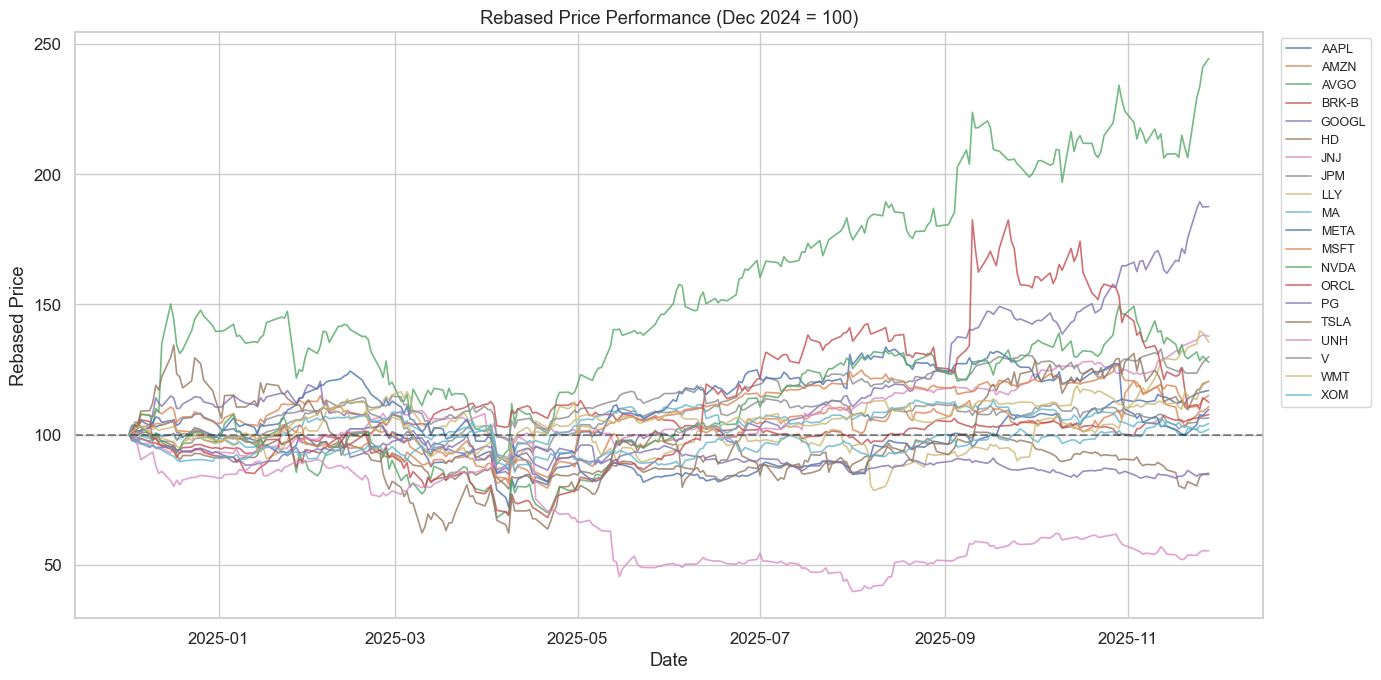

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))

for t in TICKERS:
    if t in price_frames:
        rebased = price_frames[t]['Close'] / price_frames[t]['Close'].iloc[0] * 100
        ax.plot(rebased.index, rebased.values, label=t, alpha=0.8, linewidth=1.2)

ax.axhline(100, color='black', linestyle='--', alpha=0.4)
ax.set_title('Rebased Price Performance (Dec 2024 = 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Rebased Price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_price_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Daily Drawdown by Ticker (Training Period)

The stop-loss threshold used by the Fixed+Stop ablation is calibrated from the cross-ticker mean intraday drawdown `(Low - High) / High` computed on the **model training window** (earliest processed-sentiment date through `BACKTEST_START = 2024-12-01`). Calibrating on pre-backtest data only makes the Fixed+Stop evaluation a genuine out-of-sample test of the stop-loss mechanism.

Training window: 2023-08-01 to 2024-12-01
Training-window price series loaded: 20


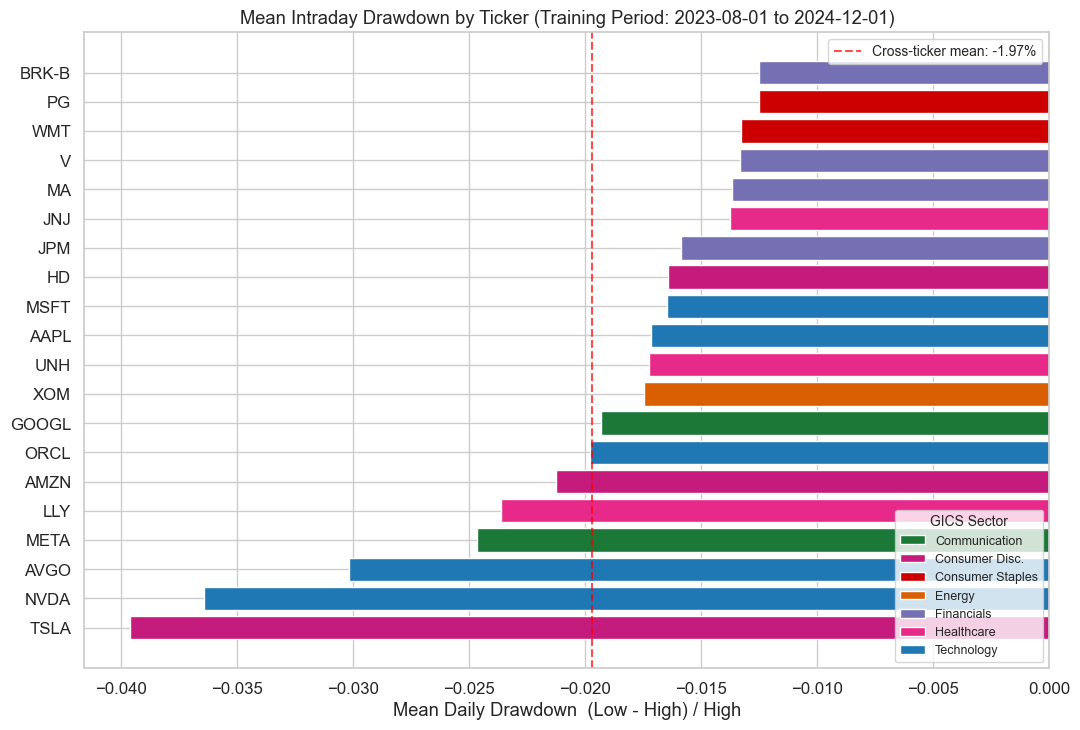

Cross-ticker mean intraday drawdown:  -1.972%
Worst ticker mean DD:  TSLA   -3.958%
Mildest ticker mean DD: BRK-B  -1.249%
STOP_LOSS_PCT (abs, rounded to 0.1%%):  2.0%


In [15]:
from matplotlib.patches import Patch

# --- Determine training window from processed sentiment data --------------
# DATA_START is the earliest date present across all loaded sentiment CSVs.
# TRAIN_END matches BACKTEST_START in the portfolio optimizer notebook.
TRAIN_EDA_START = min(df['date'].min() for df in news_frames.values()).date()
TRAIN_EDA_END   = pd.Timestamp('2024-12-01').date()   # = BACKTEST_START
print(f'Training window: {TRAIN_EDA_START} to {TRAIN_EDA_END}')

# --- Load training-window prices (separate from the backtest-window prices)
training_price_frames = {}
for t in TICKERS:
    df = yf.download(t, start=str(TRAIN_EDA_START), end=str(TRAIN_EDA_END),
                     progress=False)
    if not df.empty:
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        training_price_frames[t] = df
print(f'Training-window price series loaded: {len(training_price_frames)}')

# --- Intraday drawdown per day: (Low - High) / High ----------------------
# Peak-to-trough within the session, always <= 0.
per_ticker_mean = {}
all_dd = []
for t in TICKERS:
    if t in training_price_frames:
        df = training_price_frames[t]
        dd = ((df["Low"] - df["High"]) / df["High"]).dropna()
        per_ticker_mean[t] = dd.mean()
        all_dd.extend(dd.tolist())

dd_series = pd.Series(per_ticker_mean).sort_values(ascending=True)
overall_mean = pd.Series(all_dd).mean()

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.barh(dd_series.index, dd_series.values,
        color=[ticker_colour(t) for t in dd_series.index])
ax.set_title(f"Mean Intraday Drawdown by Ticker (Training Period: "
             f"{TRAIN_EDA_START} to {TRAIN_EDA_END})")
ax.set_xlabel("Mean Daily Drawdown  (Low - High) / High")
ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)

mean_line = ax.axvline(overall_mean, color="red", linestyle="--", alpha=0.7,
                       label=f"Cross-ticker mean: {overall_mean*100:.2f}%")

sector_handles = [Patch(facecolor=SECTOR_COLOURS[s], label=s) for s in sorted(SECTOR_COLOURS)]
sector_legend = ax.legend(handles=sector_handles, loc="lower right",
                          title="GICS Sector", title_fontsize=10,
                          fontsize=9, frameon=True, ncol=1)
ax.add_artist(sector_legend)
ax.legend(handles=[mean_line], loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / "EDA/data_daily_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cross-ticker mean intraday drawdown:  {overall_mean*100:.3f}%")
print(f"Worst ticker mean DD:  {dd_series.index[0]:<6} {dd_series.values[0]*100:.3f}%")
print(f"Mildest ticker mean DD: {dd_series.index[-1]:<6} {dd_series.values[-1]*100:.3f}%")
print(f"STOP_LOSS_PCT (abs, rounded to 0.1%%):  {round(abs(overall_mean), 3)*100:.1f}%")


## 14. Cross-Stock Price Correlation Heatmap

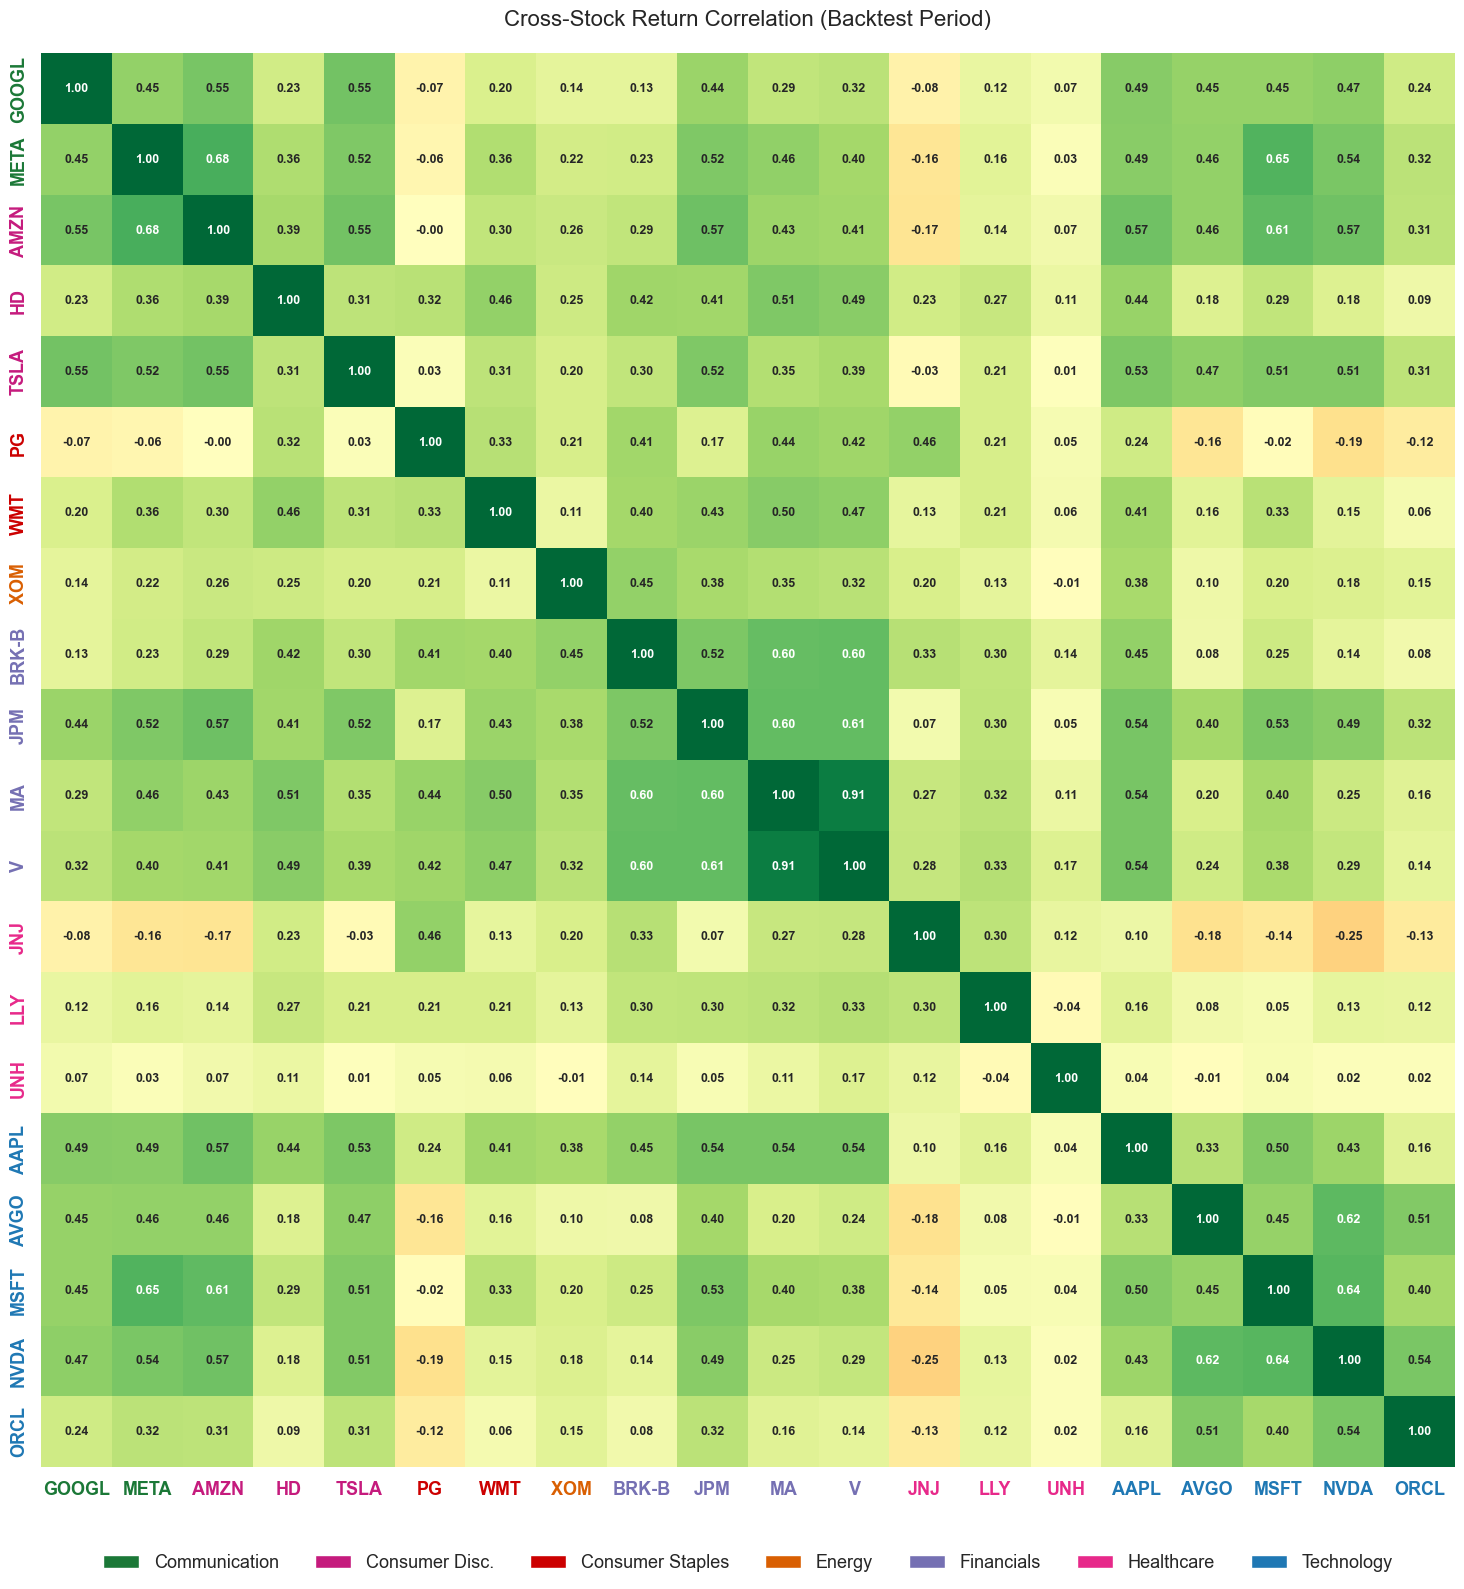

Mean intra-sector correlation: 0.4525  (n=24 pairs)
Mean inter-sector correlation: 0.2572  (n=166 pairs)


In [16]:
# Build daily returns and sort tickers by sector
returns = pd.DataFrame()
for t in TICKERS:
    if t in price_frames:
        returns[t] = price_frames[t]['Close'].pct_change()

# Sort tickers by sector for clustering
sector_order = ['Communication', 'Consumer Disc.', 'Consumer Staples',
                'Energy', 'Financials', 'Healthcare', 'Technology']
sorted_tickers = sorted(returns.columns, key=lambda x: (sector_order.index(SECTORS[x]), x))
returns = returns[sorted_tickers]

corr = returns.corr()

fig, ax = plt.subplots(figsize=(18, 16))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=1.0, cbar=False,
            annot_kws={'size': 9, 'weight': 'bold'},
            ax=ax, square=True)

ax.tick_params(labelsize=13)

# Colour the tick labels by sector
for label in ax.get_xticklabels():
    t = label.get_text()
    label.set_color(SECTOR_COLOURS[SECTORS[t]])
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    t = label.get_text()
    label.set_color(SECTOR_COLOURS[SECTORS[t]])
    label.set_fontweight('bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SECTOR_COLOURS[s], label=s) for s in sector_order]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05),
          ncol=len(sector_order), fontsize=13, title_fontsize=13, frameon=False)

ax.set_title('Cross-Stock Return Correlation (Backtest Period)', fontsize=16, pad=20)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'EDA/data_sector_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Intra vs inter sector correlation
intra, inter = [], []
for i, t1 in enumerate(sorted_tickers):
    for j, t2 in enumerate(sorted_tickers):
        if i >= j:
            continue
        val = corr.loc[t1, t2]
        if SECTORS[t1] == SECTORS[t2]:
            intra.append(val)
        else:
            inter.append(val)

print(f'Mean intra-sector correlation: {sum(intra)/len(intra):.4f}  (n={len(intra)} pairs)')
print(f'Mean inter-sector correlation: {sum(inter)/len(inter):.4f}  (n={len(inter)} pairs)')